In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:

df_temp = pd.read_csv("../../data/csv/air_pollution.csv")

In [98]:
list_IndicatorCode = ["AIR_4","AIR_5","AIR_6","AIR_7","AIR_8","AIR_9","SDGPM25"]
df = df_temp[df_temp["IndicatorCode"].isin(list_IndicatorCode)].copy()

In [99]:
df.reset_index(drop = True, inplace= True)
df.drop(columns=["Unnamed: 0"], inplace=True)


In [100]:
df.dropna(subset = ["ParentLocationCode"],axis = 0, inplace = True )
df["ParentLocationCode"].isnull().value_counts()

ParentLocationCode
False    50625
Name: count, dtype: int64

In [101]:
df["TimeDimensionBegin"] = pd.to_datetime(df["TimeDimensionBegin"], format="ISO8601")
print(df["TimeDimensionBegin"].isnull().value_counts())

df["TimeDimensionEnd"] = pd.to_datetime(df["TimeDimensionEnd"], format="ISO8601")
print(df["TimeDimensionEnd"].isnull().value_counts())

df["TimeDimensionValue"] = pd.to_datetime(df["TimeDimensionValue"], format="ISO8601")
print(df["TimeDimensionValue"].isnull().value_counts())

TimeDimensionBegin
False    50625
Name: count, dtype: int64
TimeDimensionEnd
False    50625
Name: count, dtype: int64
TimeDimensionValue
False    50625
Name: count, dtype: int64


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50625 entries, 0 to 65112
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype                    
---  ------              --------------  -----                    
 0   ParentLocationCode  50625 non-null  object                   
 1   SpatialDim          50625 non-null  object                   
 2   Value               50625 non-null  object                   
 3   NumericValue        50625 non-null  float64                  
 4   TimeDimensionBegin  50625 non-null  datetime64[ns, UTC+01:00]
 5   TimeDimensionEnd    50625 non-null  datetime64[ns, UTC+01:00]
 6   TimeDimensionValue  50625 non-null  datetime64[ns]           
 7   TimeDimType         50625 non-null  object                   
 8   TimeDim             50625 non-null  int64                    
 9   IndicatorCode       50625 non-null  object                   
dtypes: datetime64[ns, UTC+01:00](2), datetime64[ns](1), float64(1), int64(1), object(5)
mem

In [103]:
df.TimeDim

0        2019
1        2019
2        2019
3        2019
4        2019
         ... 
65108    2018
65109    2015
65110    2010
65111    2013
65112    2016
Name: TimeDim, Length: 50625, dtype: int64

In [104]:
df = df[(df["TimeDim"] >=2010)&(df["TimeDim"] <=2015)]

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25434 entries, 10359 to 65111
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype                    
---  ------              --------------  -----                    
 0   ParentLocationCode  25434 non-null  object                   
 1   SpatialDim          25434 non-null  object                   
 2   Value               25434 non-null  object                   
 3   NumericValue        25434 non-null  float64                  
 4   TimeDimensionBegin  25434 non-null  datetime64[ns, UTC+01:00]
 5   TimeDimensionEnd    25434 non-null  datetime64[ns, UTC+01:00]
 6   TimeDimensionValue  25434 non-null  datetime64[ns]           
 7   TimeDimType         25434 non-null  object                   
 8   TimeDim             25434 non-null  int64                    
 9   IndicatorCode       25434 non-null  object                   
dtypes: datetime64[ns, UTC+01:00](2), datetime64[ns](1), float64(1), int64(1), object(5)

In [106]:
df.IndicatorCode.unique()

array(['AIR_7', 'SDGPM25'], dtype=object)

<Axes: xlabel='TimeDim', ylabel='NumericValue'>

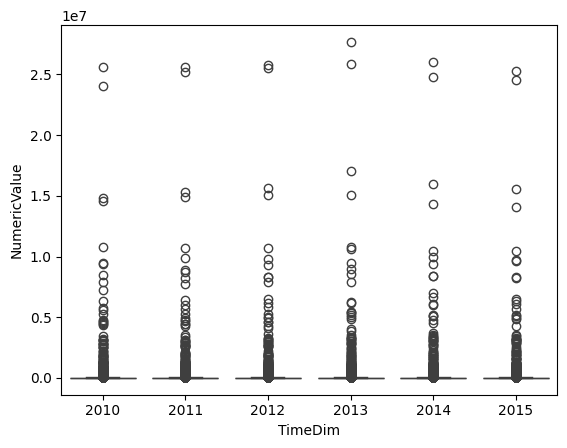

In [107]:
sns.boxplot(df, x= 'TimeDim', y = 'NumericValue')

In [108]:
df.describe()

,NumericValue,TimeDimensionValue,TimeDim
count,2.543400e+04,25434,25434.000000
mean,1.052916e+05,2012-07-02 00:00:00,2012.500000
min,9.800000e-02,2010-01-01 00:00:00,2010.000000
25%,5.937085e+01,2011-01-01 00:00:00,2011.000000
50%,3.253691e+03,2012-07-02 00:00:00,2012.500000
75%,2.817913e+04,2014-01-01 00:00:00,2014.000000
max,2.767364e+07,2015-01-01 00:00:00,2015.000000
std,8.027423e+05,NaN,1.707859


In [109]:
#Log
df["Numeric_log"] = np.log1p(df["NumericValue"])

#RobustScaler
from sklearn.preprocessing import RobustScaler,MinMaxScaler
scaler = RobustScaler()
df["Numeric_robust"] = scaler.fit_transform(df[["Numeric_log"]])

#Chuẩn hóa về [0,1]
minmax = MinMaxScaler()
df["Numeric_final"] = minmax.fit_transform(df[["Numeric_robust"]]).round(4)

In [110]:
df.describe()

,NumericValue,TimeDimensionValue,TimeDim,Numeric_log,Numeric_robust,Numeric_final
count,2.543400e+04,25434,25434.000000,25434.000000,2.543400e+04,25434.000000
mean,1.052916e+05,2012-07-02 00:00:00,2012.500000,7.576965,-8.312707e-02,0.439106
min,9.800000e-02,2010-01-01 00:00:00,2010.000000,0.093490,-1.300771e+00,0.000000
25%,5.937085e+01,2011-01-01 00:00:00,2011.000000,4.100506,-6.487851e-01,0.235100
50%,3.253691e+03,2012-07-02 00:00:00,2012.500000,8.087853,1.445174e-16,0.469100
75%,2.817913e+04,2014-01-01 00:00:00,2014.000000,10.246372,3.512149e-01,0.595700
max,2.767364e+07,2015-01-01 00:00:00,2015.000000,17.135991,1.472232e+00,1.000000
std,8.027423e+05,NaN,1.707859,3.383515,5.505351e-01,0.198534


In [111]:
df_outlier_scale = df[["ParentLocationCode","SpatialDim","IndicatorCode","TimeDim","Numeric_final"]]
df_outlier_scale.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25434 entries, 10359 to 65111
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ParentLocationCode  25434 non-null  object 
 1   SpatialDim          25434 non-null  object 
 2   IndicatorCode       25434 non-null  object 
 3   TimeDim             25434 non-null  int64  
 4   Numeric_final       25434 non-null  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 1.2+ MB


In [113]:
df_outlier_scale.describe()

,TimeDim,Numeric_final
count,25434.000000,25434.000000
mean,2012.500000,0.439106
std,1.707859,0.198534
min,2010.000000,0.000000
25%,2011.000000,0.235100
50%,2012.500000,0.469100
75%,2014.000000,0.595700
max,2015.000000,1.000000


In [114]:
df_outlier_scale.to_csv("csv_temp_air_outlier.csv", index = False)

In [117]:
df_outlier_scale.columns

Index(['ParentLocationCode', 'SpatialDim', 'IndicatorCode', 'TimeDim',
       'Numeric_final'],
      dtype='object')

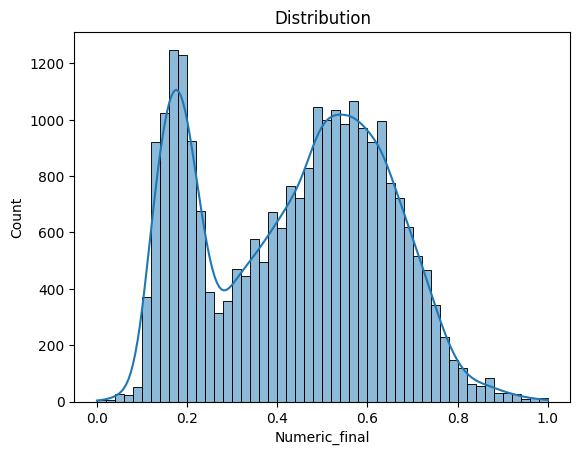

In [118]:
sns.histplot(df_outlier_scale["Numeric_final"], bins = 50, kde = True)
plt.title("Distribution")
plt.show()

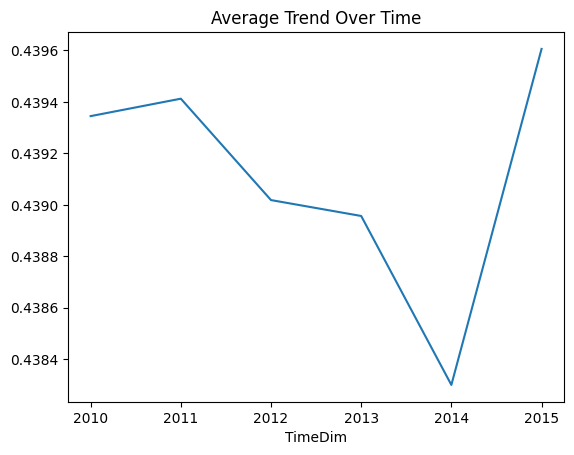

In [122]:
df_outlier_scale.groupby("TimeDim")["Numeric_final"].mean().plot()
plt.title("Average Trend Over Time")
plt.show()


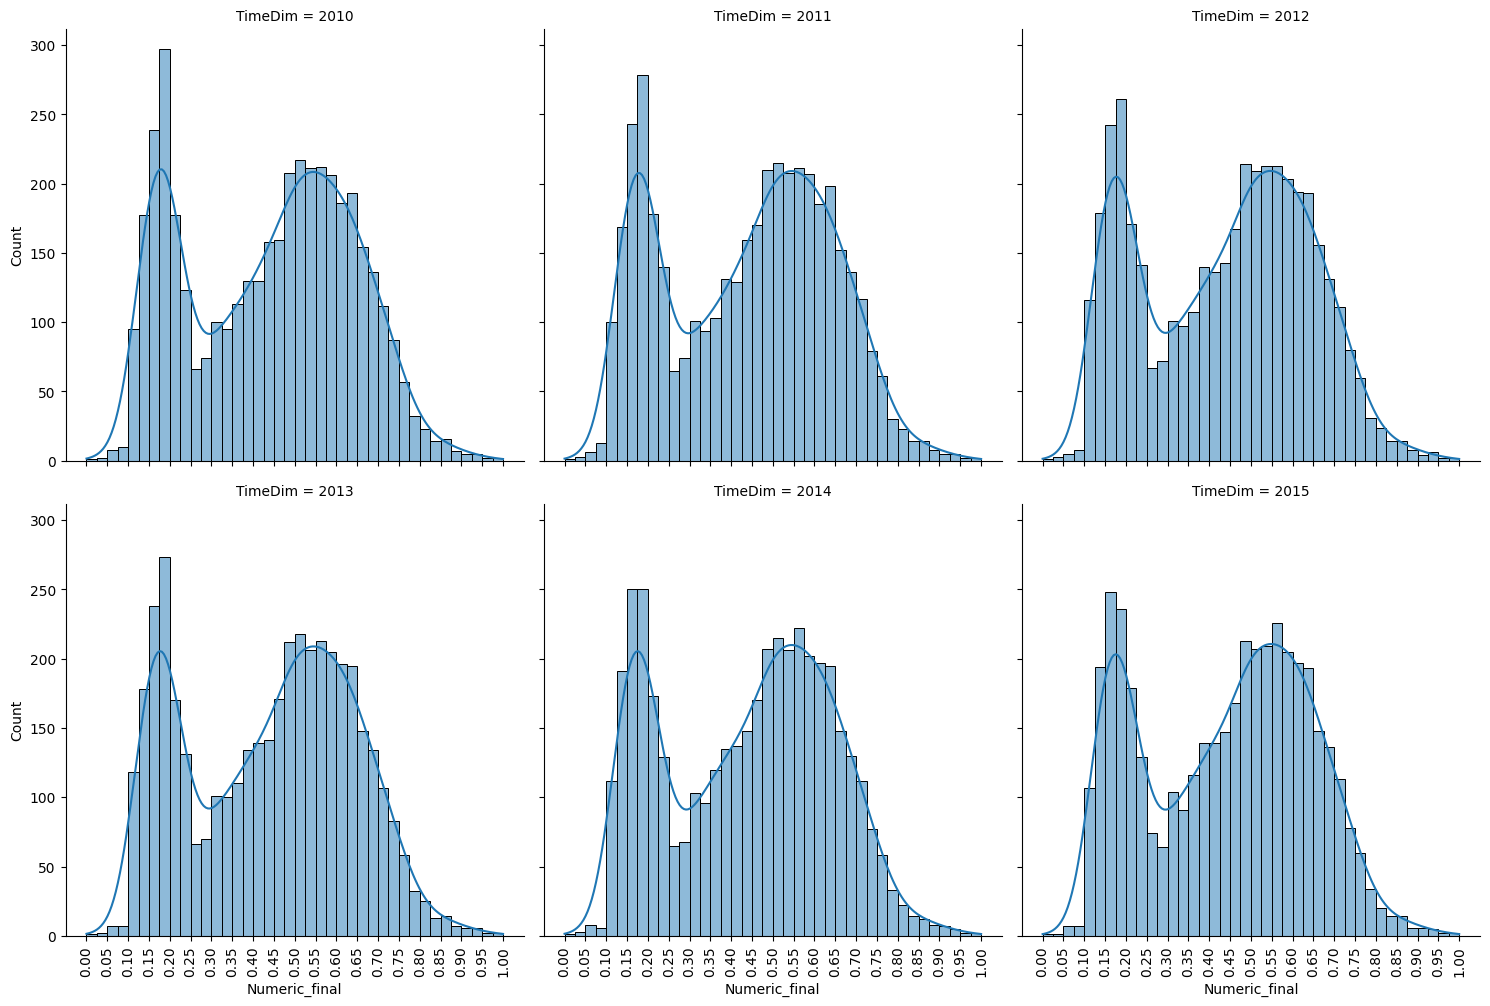

In [129]:
g=sns.displot(
    data=df_outlier_scale,
    x="Numeric_final",
    col="TimeDim",
    col_wrap=3,
    bins=40,
    kde=True
)
for ax in g.axes.flatten():
    ax.set_xticks(np.arange(0, 1.05, 0.05))
    ax.tick_params(axis='x', rotation=90)

plt.show()
